In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions

In [2]:
dataset = pd.read_csv("../datasets/iris_multiclass.csv")
dataset.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.2,3.5,1.0,0.2,setosa
1,6.6,2.8,5.5,1.9,virginica
2,6.8,2.9,3.6,1.5,versicolor
3,5.5,2.7,4.6,1.1,versicolor
4,5.4,2.8,2.6,1.1,versicolor


In [3]:
dataset["species"].unique()

array(['setosa', 'virginica', 'versicolor'], dtype=object)

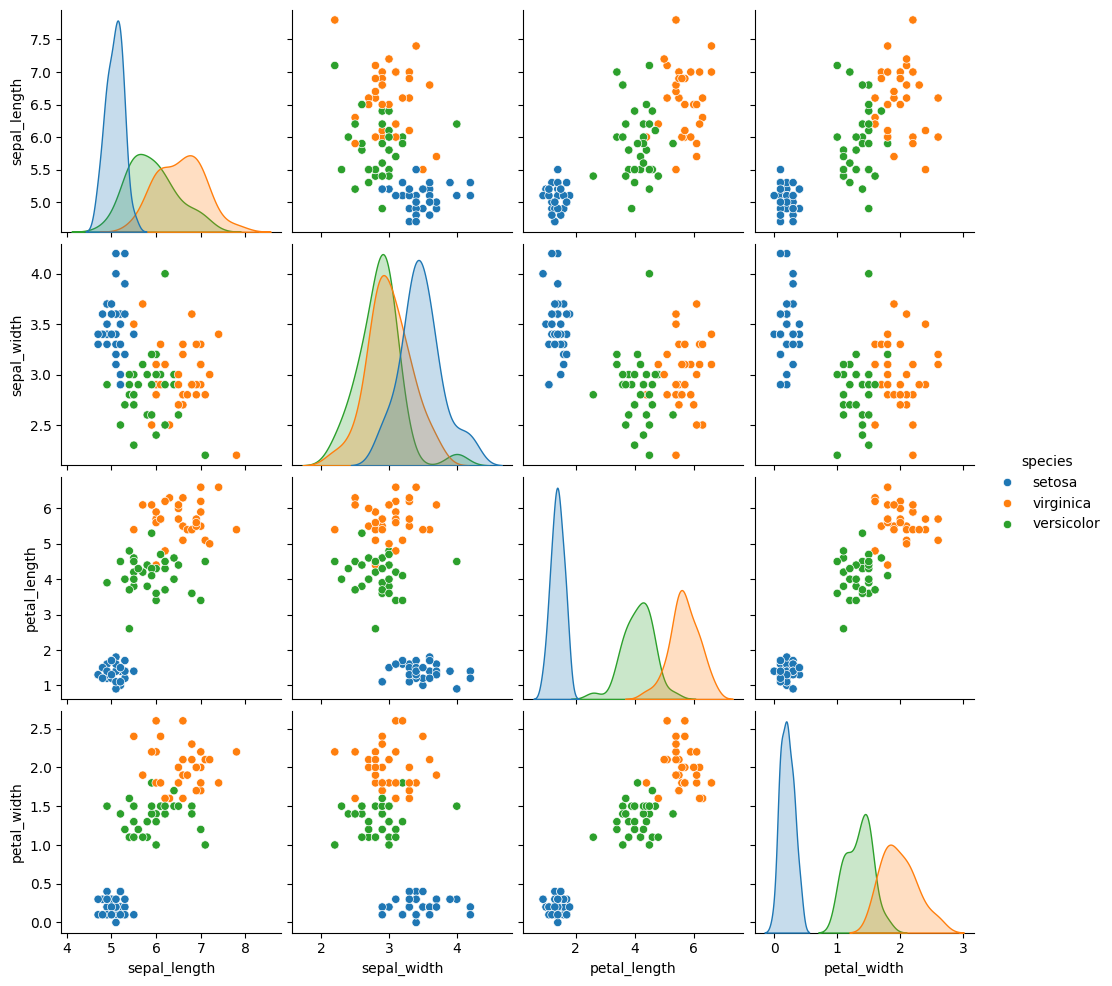

In [4]:
sns.pairplot(data=dataset,hue="species")

In [5]:
x = dataset.iloc[:,:-1]
y= dataset["species"]


In [6]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

ovr

In [7]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
lr.score(x_test,y_test)*100

100.0

multinomial

In [9]:
lr2 = LogisticRegression(multi_class="multinomial")
lr2.fit(x_train,y_train)

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
lr2.score(x_test,y_test)*100

direcct

In [ ]:
lr3 = LogisticRegression()
lr3.fit(x_train,y_train)

In [10]:
lr3.score(x_test,y_test)*100

NameError: name 'lr3' is not defined

In [12]:
manual_test = pd.DataFrame([
    [5.0, 3.4, 1.5, 0.2],  # Sample 1
    [6.0, 2.9, 4.5, 1.5],  # Sample 2
    [7.1, 3.0, 5.9, 2.1]   # Sample 3
], columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])

print("Manual test samples:\n", manual_test)

Manual test samples:
    sepal_length  sepal_width  petal_length  petal_width
0           5.0          3.4           1.5          0.2
1           6.0          2.9           4.5          1.5
2           7.1          3.0           5.9          2.1


In [14]:
# Using the trained model 'lr'
predicted_species = lr.predict(manual_test)

# Show predicted species
for i, species in enumerate(predicted_species):
    print(f"Sample {i+1} predicted species: {species}")

Sample 1 predicted species: setosa
Sample 2 predicted species: versicolor
Sample 3 predicted species: virginica


In [15]:
# Predict probability for each class
pred_probs = lr.predict_proba(manual_test)

for i, probs in enumerate(pred_probs):
    print(f"Sample {i+1} probabilities:")
    for cls, prob in zip(lr.classes_, probs):
        print(f"  {cls}: {prob:.2f}")


Sample 1 probabilities:
  setosa: 0.96
  versicolor: 0.04
  virginica: 0.00
Sample 2 probabilities:
  setosa: 0.01
  versicolor: 0.77
  virginica: 0.22
Sample 3 probabilities:
  setosa: 0.00
  versicolor: 0.03
  virginica: 0.97
